<center><H1 style = "color: green">ML Project : Heart Disease Prediction</H1> </center>

## Exploitary Data Analysis

In [1]:
# importing necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv('heart_disease_synthetic_10000.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,66,F,ASY,133,202,0,LVH,154,N,0.9,Down,1
1,79,M,ASY,112,250,0,ST,142,N,1.0,Up,1
2,56,M,ASY,110,295,0,Normal,188,N,2.0,Up,0
3,42,M,TA,136,277,0,Normal,168,N,1.5,Up,0
4,70,M,ASY,166,273,0,Normal,176,N,0.6,Down,1


In [4]:
# no.of columns and rows
df.shape

(10000, 12)

In [5]:
# checking null values and datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10000 non-null  int64  
 1   Sex             10000 non-null  object 
 2   ChestPainType   10000 non-null  object 
 3   RestingBP       10000 non-null  int64  
 4   Cholesterol     10000 non-null  int64  
 5   FastingBS       10000 non-null  int64  
 6   RestingECG      10000 non-null  object 
 7   MaxHR           10000 non-null  int64  
 8   ExerciseAngina  10000 non-null  object 
 9   Oldpeak         10000 non-null  float64
 10  ST_Slope        10000 non-null  object 
 11  HeartDisease    10000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 937.6+ KB


In [6]:
# checking duplicated values
df.duplicated().sum()

np.int64(0)

In [7]:
# classifying numerical columns and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

print(numerical_cols)
print(categorical_cols)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')
Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [8]:
# statistical summary of numerical column
df[numerical_cols].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54.021700,132.254900,245.189400,0.260600,169.756900,1.209850,0.620000
std,15.203998,17.776089,54.945102,0.438984,20.593417,0.992042,0.485411
min,28.000000,90.000000,100.000000,0.000000,85.000000,0.000000,0.000000
25%,41.000000,120.000000,208.000000,0.000000,156.000000,0.500000,0.000000
50%,54.000000,132.000000,245.000000,0.000000,170.000000,0.900000,1.000000
75%,67.000000,144.000000,282.000000,1.000000,185.000000,1.700000,1.000000
max,80.000000,198.000000,470.000000,1.000000,210.000000,6.000000,1.000000


In [9]:
# summary of categorical column
df[categorical_cols].describe()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,10000,10000,10000,10000,10000
unique,2,4,3,2,3
top,M,ASY,Normal,N,Up
freq,6807,4940,6023,6531,4574


### Univariate Analysis

<Axes: xlabel='Age', ylabel='Count'>

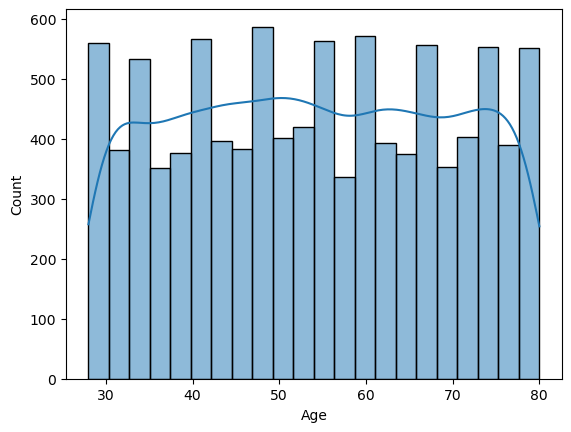

In [10]:
sns.histplot(df['Age'],kde = True)

<Axes: xlabel='RestingBP', ylabel='Count'>

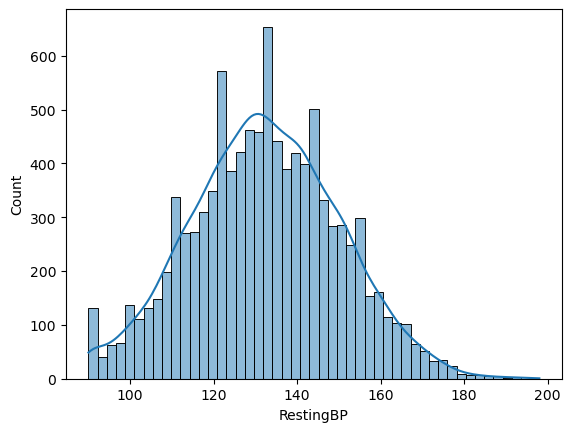

In [11]:
sns.histplot(df['RestingBP'],kde = True)

<Axes: xlabel='Cholesterol', ylabel='Count'>

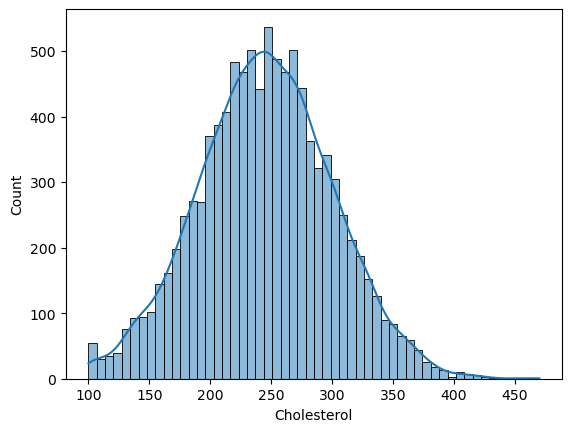

In [12]:
sns.histplot(df['Cholesterol'],kde = True)

<Axes: xlabel='MaxHR', ylabel='Count'>

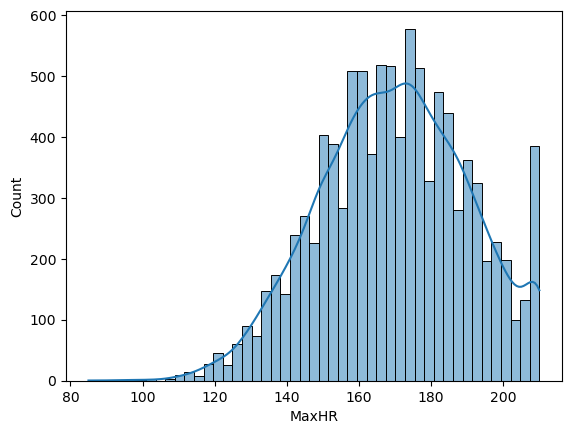

In [13]:
sns.histplot(df['MaxHR'],kde = True)

<Axes: xlabel='Oldpeak', ylabel='Count'>

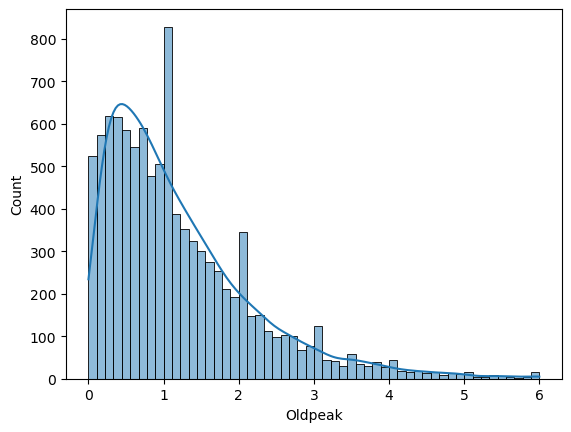

In [14]:
sns.histplot(df['Oldpeak'],kde = True)

<Axes: xlabel='ChestPainType', ylabel='count'>

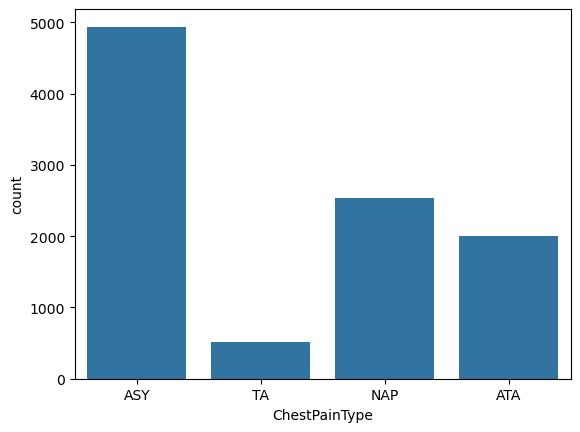

In [15]:
sns.countplot(x = 'ChestPainType',data = df)

<Axes: xlabel='Sex', ylabel='count'>

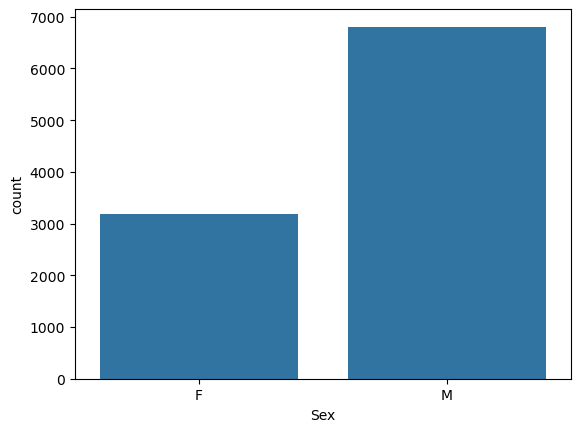

In [16]:
sns.countplot(x = 'Sex',data = df)

<Axes: xlabel='FastingBS', ylabel='count'>

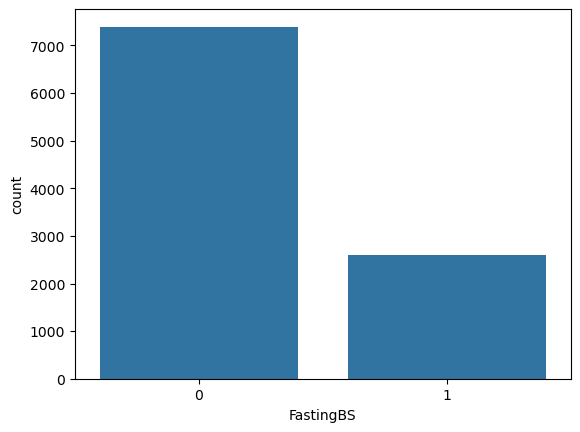

In [17]:
sns.countplot(x = 'FastingBS',data = df)

<Axes: xlabel='RestingECG', ylabel='count'>

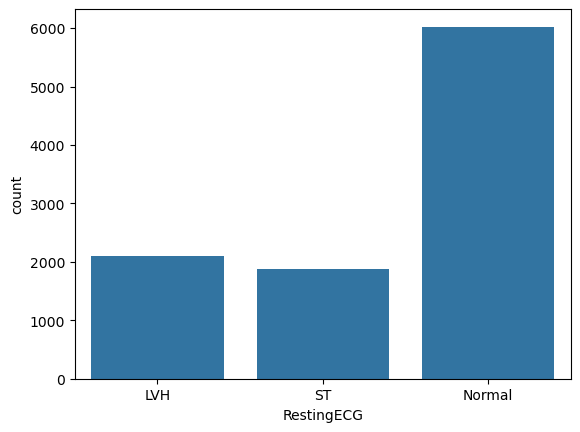

In [18]:
sns.countplot(x = 'RestingECG',data = df)

<Axes: xlabel='ExerciseAngina', ylabel='count'>

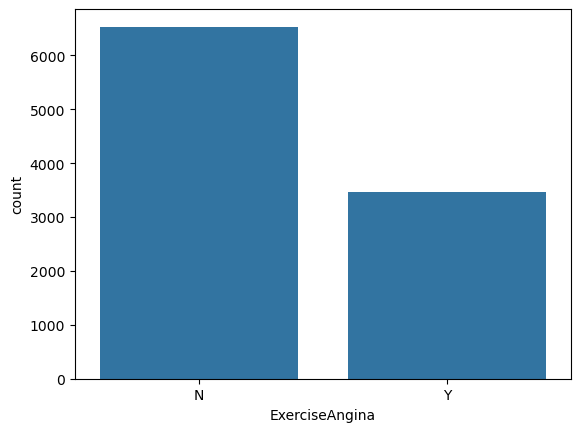

In [19]:
sns.countplot(x = 'ExerciseAngina',data = df)

<Axes: xlabel='ST_Slope', ylabel='count'>

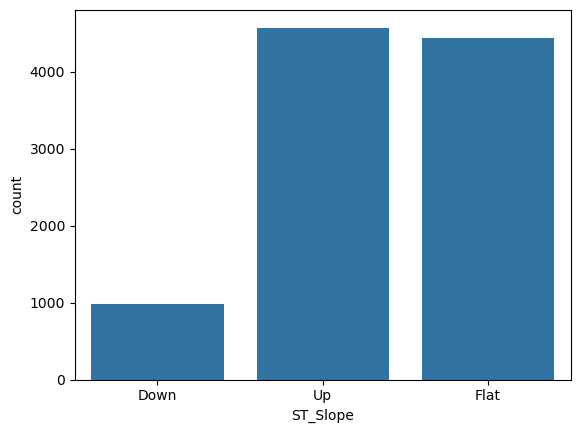

In [20]:
sns.countplot(x = 'ST_Slope',data = df)

### Target Analysis

In [21]:
df['HeartDisease'].value_counts()

HeartDisease
1    6200
0    3800
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

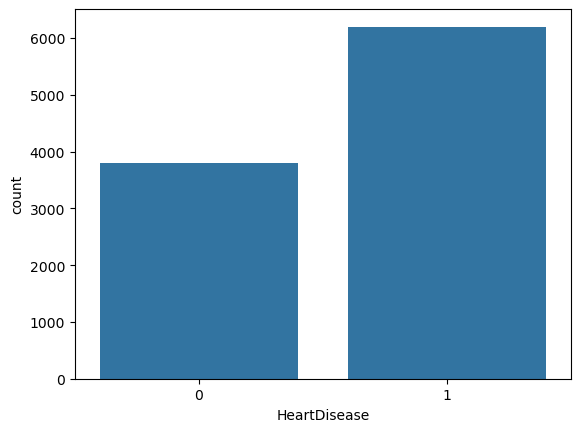

In [22]:
sns.countplot(x = 'HeartDisease',data = df)

### Checking Outliers and Removing Outliers

<Axes: xlabel='Age'>

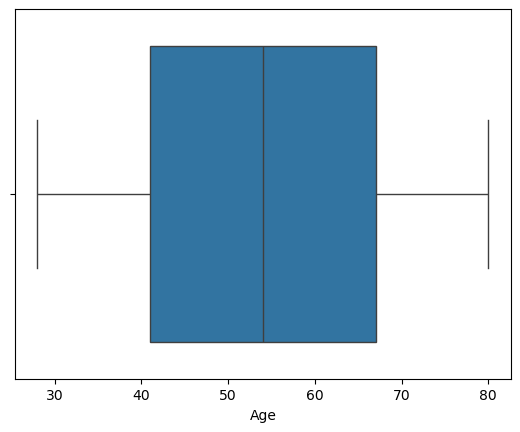

In [23]:
sns.boxplot(x = df['Age'])

<Axes: xlabel='RestingBP'>

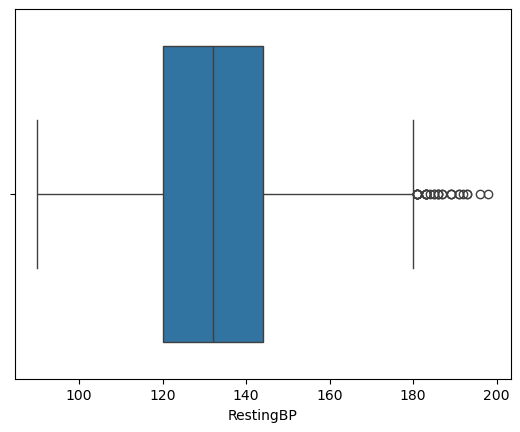

In [24]:
sns.boxplot(x = df['RestingBP'])

In [25]:
Q1 = df['RestingBP'].quantile(0.25)
Q3 = df['RestingBP'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('lower_limit-',lower_limit)
print('upper_limit-',upper_limit)

lower_limit- 84.0
upper_limit- 180.0


In [26]:
df['RestingBP'] = df['RestingBP'].clip(lower = lower_limit,upper = upper_limit)

<Axes: xlabel='RestingBP'>

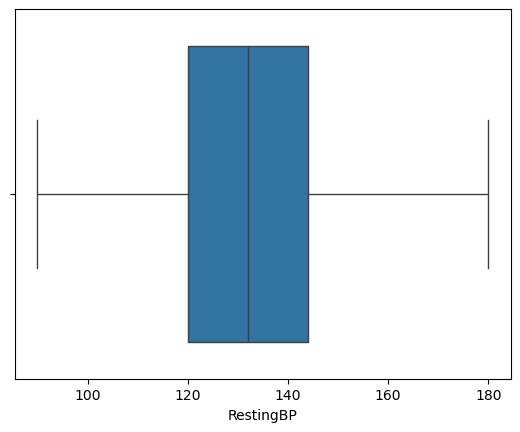

In [27]:
sns.boxplot(x = df['RestingBP'])

<Axes: xlabel='Cholesterol'>

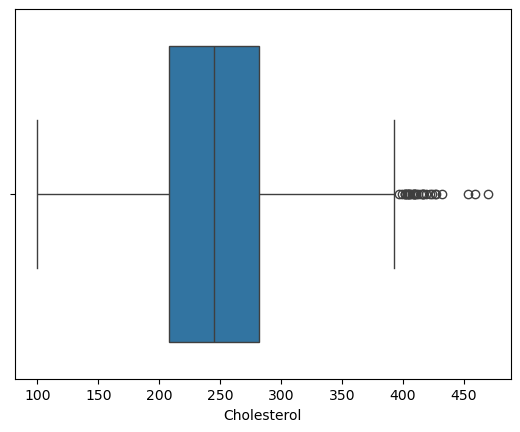

In [28]:
sns.boxplot(x = df['Cholesterol'])

In [29]:
Q1 = df['Cholesterol'].quantile(0.25)
Q3 = df['Cholesterol'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('lower_limit-',lower_limit)
print('upper_limit-',upper_limit)

lower_limit- 97.0
upper_limit- 393.0


In [30]:
df['Cholesterol'] = df['Cholesterol'].clip(lower = lower_limit,upper = upper_limit)

<Axes: xlabel='Cholesterol'>

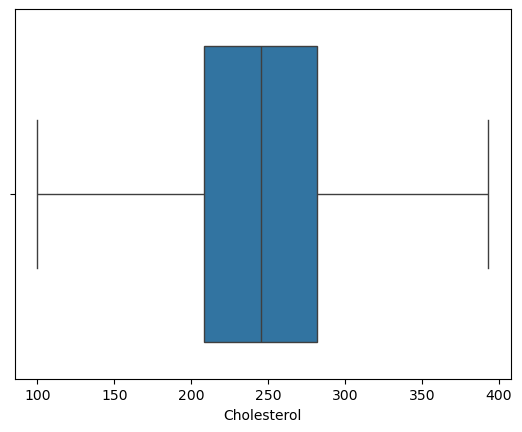

In [31]:
sns.boxplot(x = df['Cholesterol'])

<Axes: xlabel='MaxHR'>

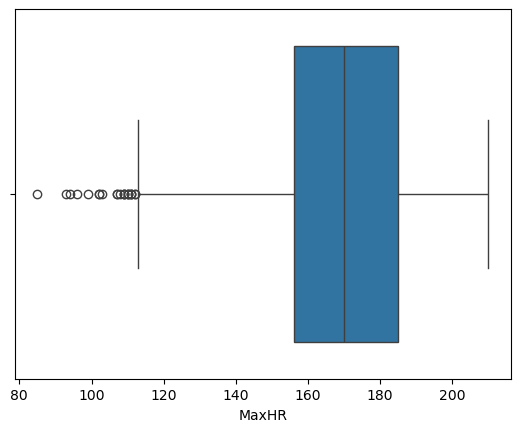

In [32]:
sns.boxplot(x = df['MaxHR'])

In [33]:
Q1 = df['MaxHR'].quantile(0.25)
Q3 = df['MaxHR'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('lower_limit-',lower_limit)
print('upper_limit-',upper_limit)

lower_limit- 112.5
upper_limit- 228.5


In [34]:
df['MaxHR'] = df['MaxHR'].clip(lower = lower_limit,upper = upper_limit)

<Axes: xlabel='MaxHR'>

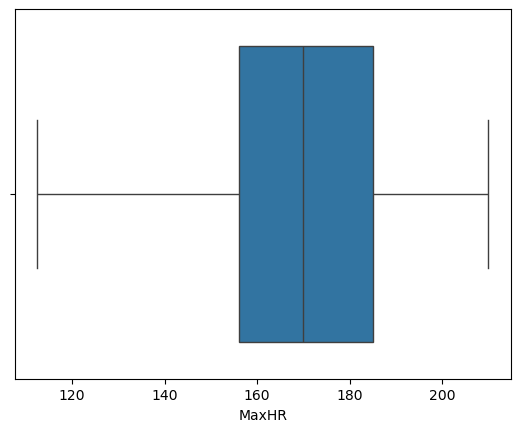

In [35]:
sns.boxplot(x = df['MaxHR'])

<Axes: xlabel='Oldpeak'>

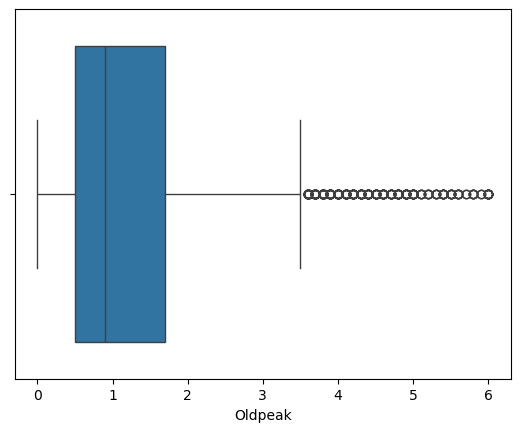

In [36]:
sns.boxplot(x = df['Oldpeak'])

In [37]:
Q1 = df['Oldpeak'].quantile(0.25)
Q3 = df['Oldpeak'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('lower_limit-',lower_limit)
print('upper_limit-',upper_limit)

lower_limit- -1.2999999999999998
upper_limit- 3.5


In [38]:
df['Oldpeak'] = df['Oldpeak'].clip(lower = lower_limit,upper = upper_limit)

<Axes: xlabel='Oldpeak'>

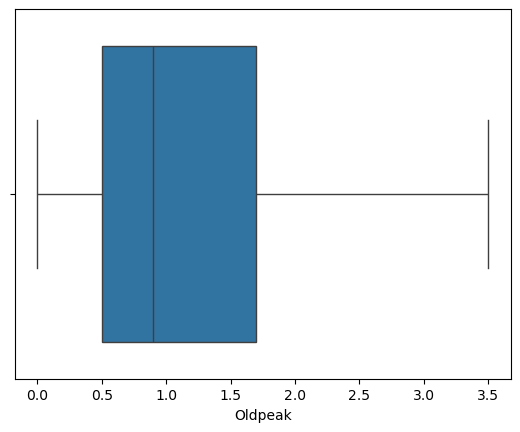

In [39]:
sns.boxplot(x = df['Oldpeak'])

### Processed Data

In [40]:
df.to_csv('heart_processed.csv', index=False)

### Bivariate Analysis for numerical columns

<Axes: xlabel='HeartDisease', ylabel='Age'>

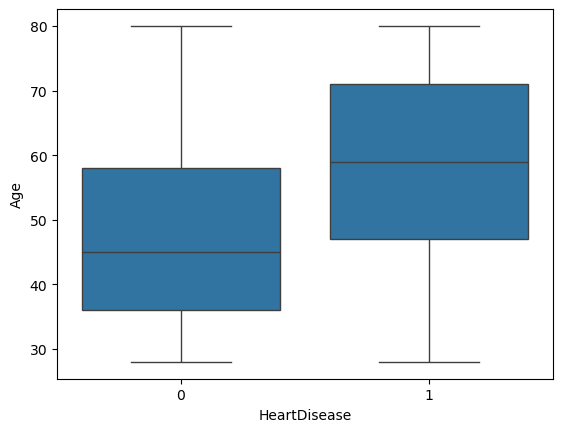

In [41]:
sns.boxplot(x = 'HeartDisease',y = 'Age',data = df)

<Axes: xlabel='HeartDisease', ylabel='RestingBP'>

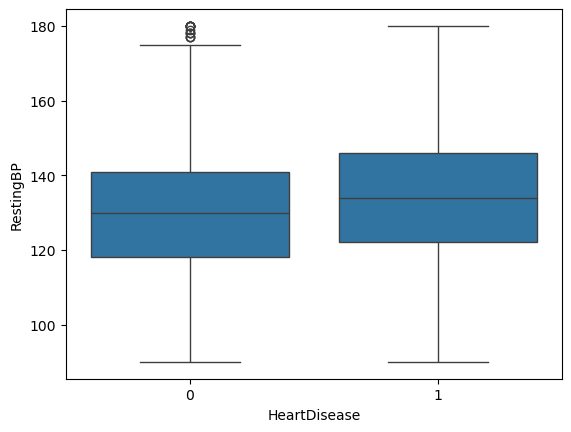

In [42]:
sns.boxplot(x = 'HeartDisease',y = 'RestingBP',data = df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

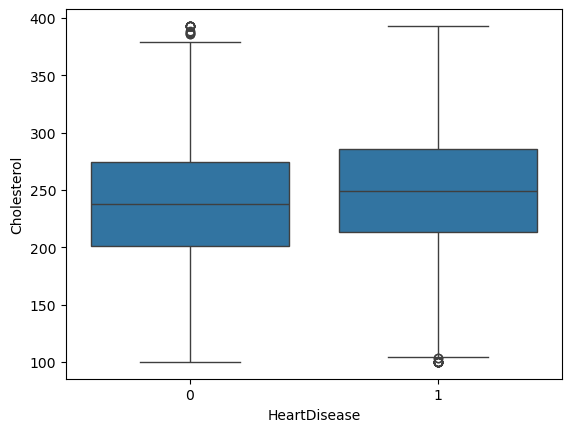

In [43]:
sns.boxplot(x = 'HeartDisease',y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

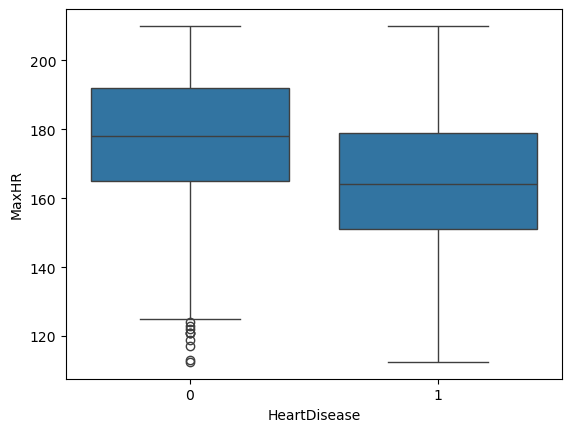

In [44]:
sns.boxplot(x = 'HeartDisease',y = 'MaxHR',data = df)

<Axes: xlabel='HeartDisease', ylabel='Oldpeak'>

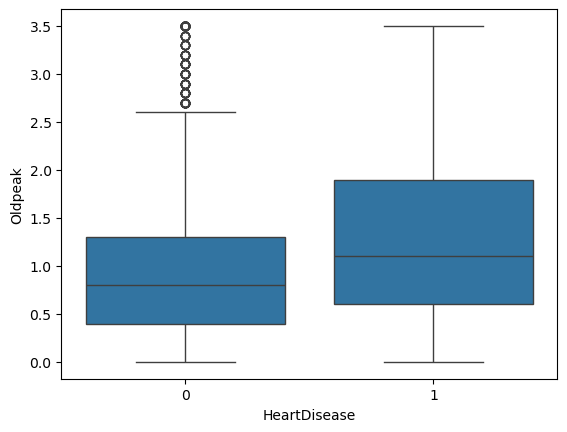

In [45]:
sns.boxplot(x = 'HeartDisease',y = 'Oldpeak',data = df)

### Bivariate Analysis for categorical columns

<Axes: xlabel='ChestPainType', ylabel='count'>

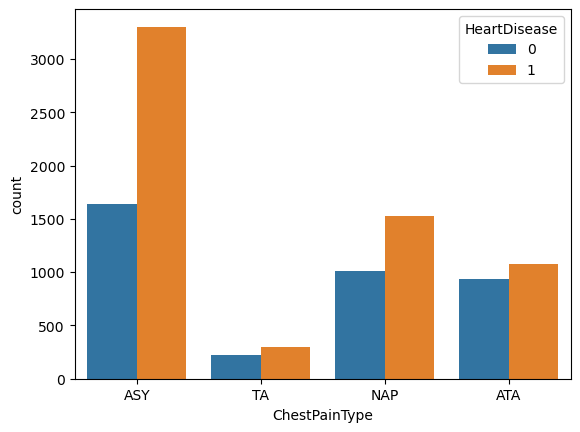

In [46]:
sns.countplot(x = 'ChestPainType', hue = 'HeartDisease', data = df)

<Axes: xlabel='Sex', ylabel='count'>

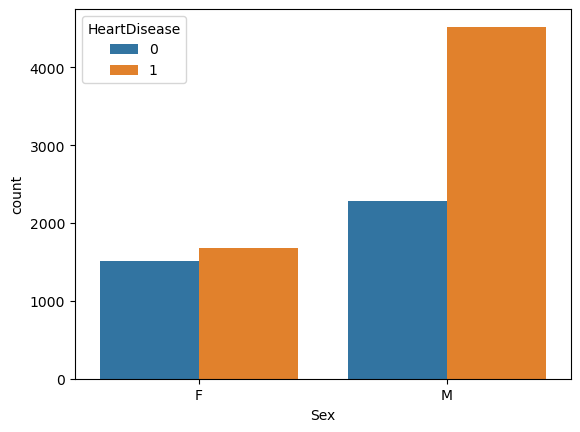

In [47]:
sns.countplot(x = 'Sex', hue = 'HeartDisease', data = df)

<Axes: xlabel='FastingBS', ylabel='count'>

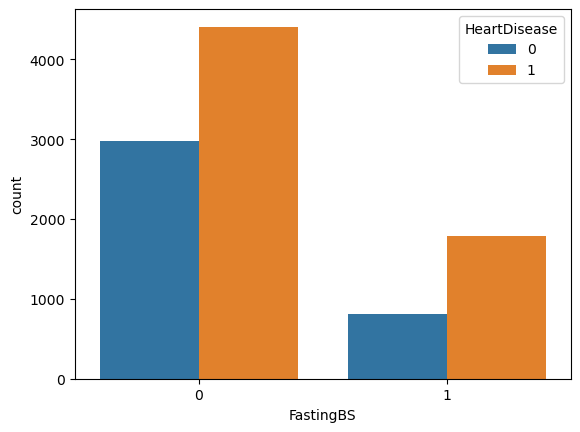

In [48]:
sns.countplot(x = 'FastingBS', hue = 'HeartDisease', data = df)

<Axes: xlabel='RestingECG', ylabel='count'>

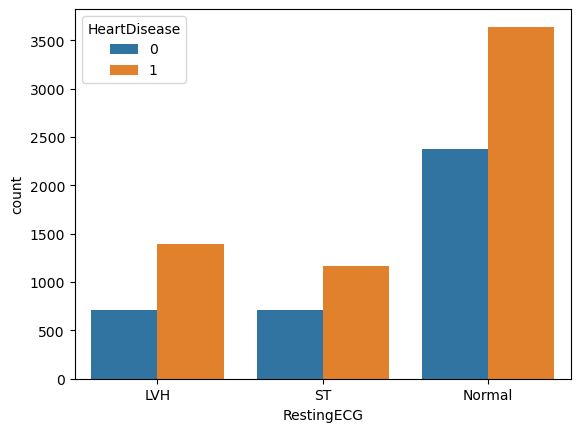

In [49]:
sns.countplot(x = 'RestingECG', hue = 'HeartDisease', data = df)

<Axes: xlabel='ExerciseAngina', ylabel='count'>

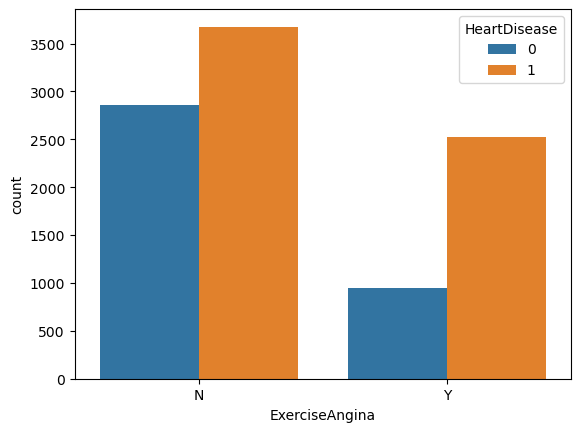

In [50]:
sns.countplot(x = 'ExerciseAngina', hue = 'HeartDisease', data = df)

<Axes: xlabel='ST_Slope', ylabel='count'>

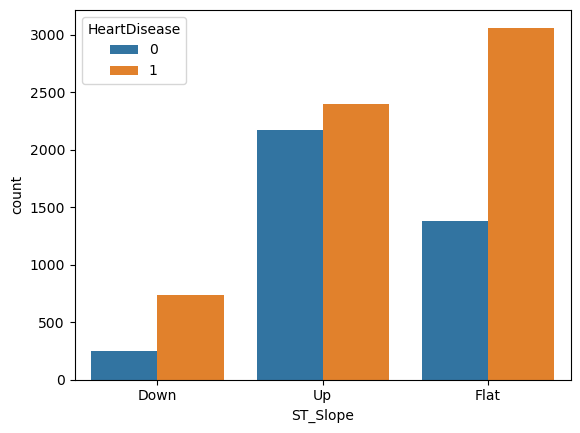

In [51]:
sns.countplot(x = 'ST_Slope', hue = 'HeartDisease', data = df)

### Correlation Analysis

<Axes: >

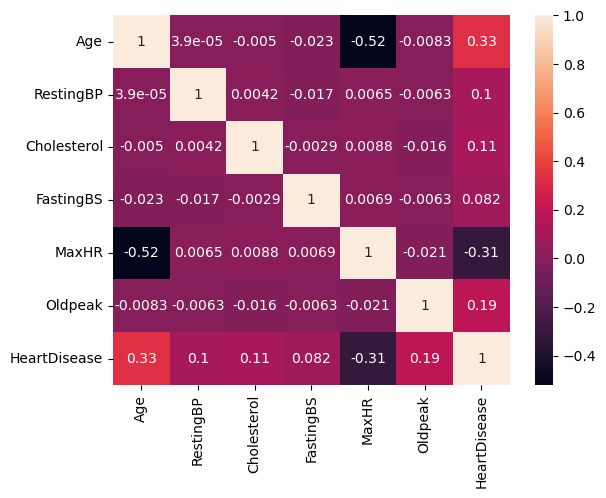

In [52]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot = True)

### Final EDA Insights

* The dataset contains 10,000 rows and 12 columns.
* The dataset contains both numerical and categorical variables
         * Numerical variables stores integer and float type 
         * Categorical variables stores object type.
* There is no missing values and duplicate records.

* Target Variable - Heart disease
         *Target Variable contains two classes 0 and 1,and class 1 has a little higher proportion.And also the target variable is slightly imbalanced.

* There are outliers are identified some numerical features using boxplot and the outliers were treated using IQR based clipping.

* The univariate and bivariate analysis indicates that Age, Oldpeak, MaxHR, ChestPainType, ExerciseAngina, and ST_Slope show noticeable 
  relationships with HeartDisease.
  
* Patients with heart disease tend to be older, have higher Oldpeak and lower MaxHR.
  
* Categorical variables like chest pain = ASY, ExerciseAngina = Y and ST_Slope = Flat/Down are more frequently associated with heart disease.RestingBP     and Cholesterol show comparatively weaker differences between the two groups.
